In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('student_performance_dataset.csv')

In [3]:
df.head()

,Student_ID,Gender,Age,Study_Hours_Per_Day,Attendance_Percentage,Previous_Exam_Score,Assignments_Completed,Sleep_Hours,Internet_Usage_Hours,Social_Media_Hours,Extra_Curricular,Family_Income,Parental_Education,Distance_From_College_km,Class_Participation,Stress_Level,Final_Exam_Score
0,1,Male,17,5.3,56.1,52.3,7,5.1,1.7,5.3,Yes,Low,High School,15.7,9,2,61.5
1,2,Female,21,0.7,63.9,75.9,17,6.4,4.1,2.3,Yes,Low,Graduate,4.0,1,3,50.9
2,3,Female,20,3.3,71.2,56.7,8,8.1,6.1,4.0,Yes,Low,Postgraduate,7.6,7,2,56.5
3,4,Female,18,2.7,58.6,49.7,3,6.2,4.2,5.9,Yes,High,Postgraduate,8.1,3,6,32.7
4,5,Female,23,4.0,67.1,93.3,17,5.5,3.3,5.5,No,Low,High School,27.5,1,4,69.3


In [4]:
df = df.drop(columns=[
    'Student_ID',
    'Internet_Usage_Hours',
    'Family_Income',
    'Parental_Education',
    'Distance_From_College_km',
    'Class_Participation'
])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 2000 non-null   object 
 1   Age                    2000 non-null   int64  
 2   Study_Hours_Per_Day    2000 non-null   float64
 3   Attendance_Percentage  2000 non-null   float64
 4   Previous_Exam_Score    2000 non-null   float64
 5   Assignments_Completed  2000 non-null   int64  
 6   Sleep_Hours            2000 non-null   float64
 7   Social_Media_Hours     2000 non-null   float64
 8   Extra_Curricular       2000 non-null   object 
 9   Stress_Level           2000 non-null   int64  
 10  Final_Exam_Score       2000 non-null   float64
dtypes: float64(6), int64(3), object(2)
memory usage: 172.0+ KB


In [6]:
df.describe()

,Age,Study_Hours_Per_Day,Attendance_Percentage,Previous_Exam_Score,Assignments_Completed,Sleep_Hours,Social_Media_Hours,Stress_Level,Final_Exam_Score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.00000
mean,20.500000,4.143000,77.744250,66.762050,10.119000,6.740300,3.67915,5.573500,58.95815
std,2.278288,2.168994,13.037509,18.289109,6.020711,1.321457,1.88938,2.905309,13.15819
min,17.000000,0.500000,55.000000,35.000000,0.000000,4.500000,0.50000,1.000000,20.90000
25%,18.750000,2.300000,66.200000,50.800000,5.000000,5.600000,2.00000,3.000000,49.70000
50%,21.000000,4.100000,78.200000,67.300000,10.000000,6.700000,3.65000,6.000000,59.10000
75%,22.000000,6.000000,88.600000,82.600000,15.000000,7.900000,5.20000,8.000000,68.10000
max,24.000000,8.000000,100.000000,98.000000,20.000000,9.000000,7.00000,10.000000,100.00000


In [7]:
df.isnull().sum()

Gender                   0
Age                      0
Study_Hours_Per_Day      0
Attendance_Percentage    0
Previous_Exam_Score      0
Assignments_Completed    0
Sleep_Hours              0
Social_Media_Hours       0
Extra_Curricular         0
Stress_Level             0
Final_Exam_Score         0
dtype: int64

<Axes: >

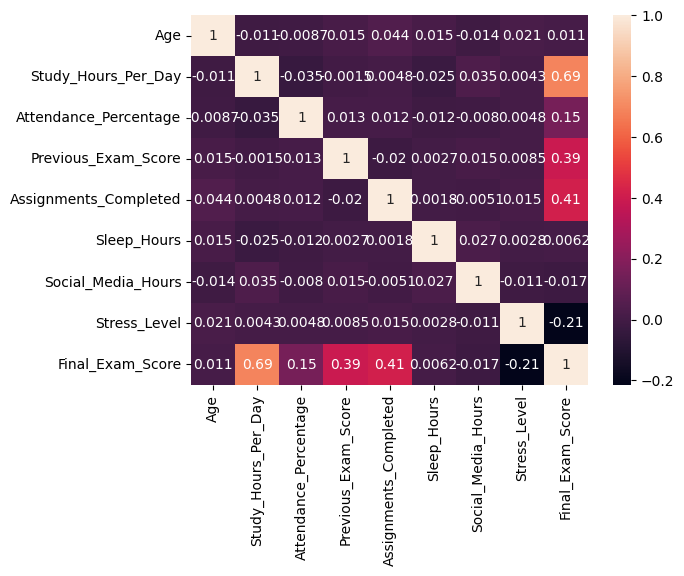

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

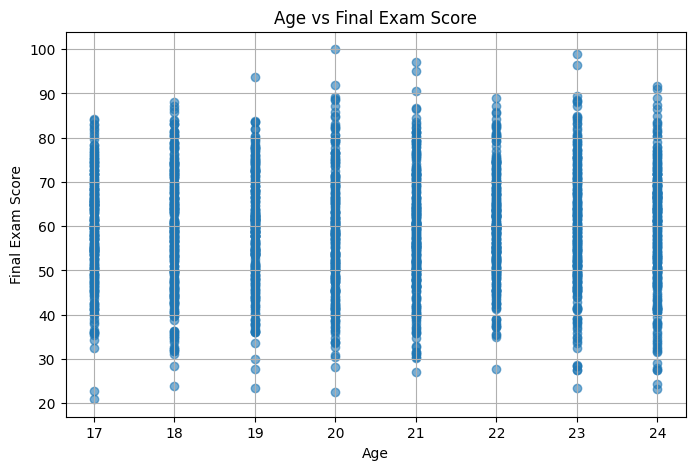

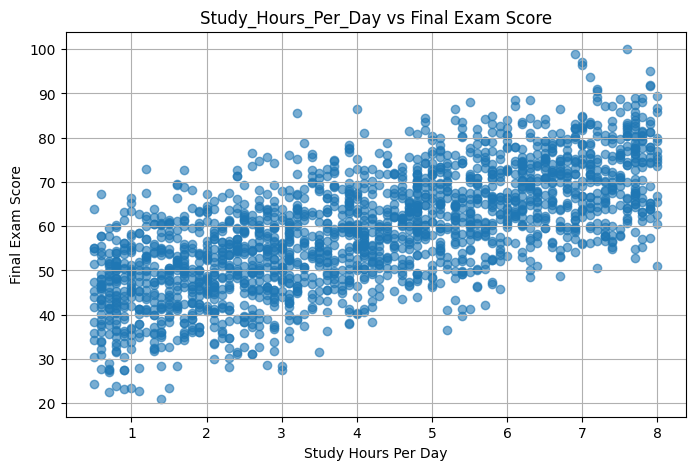

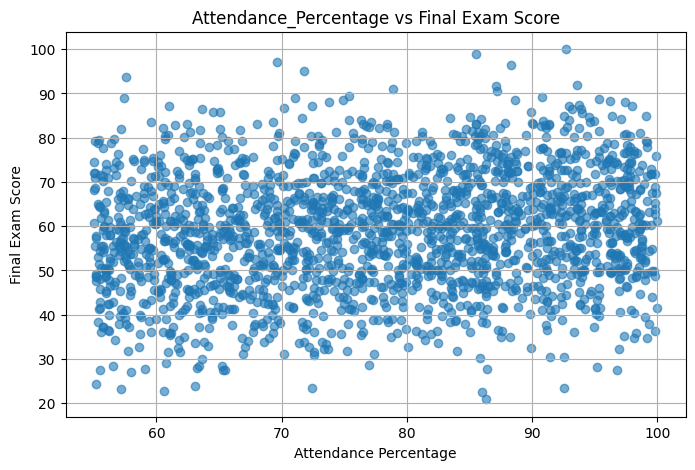

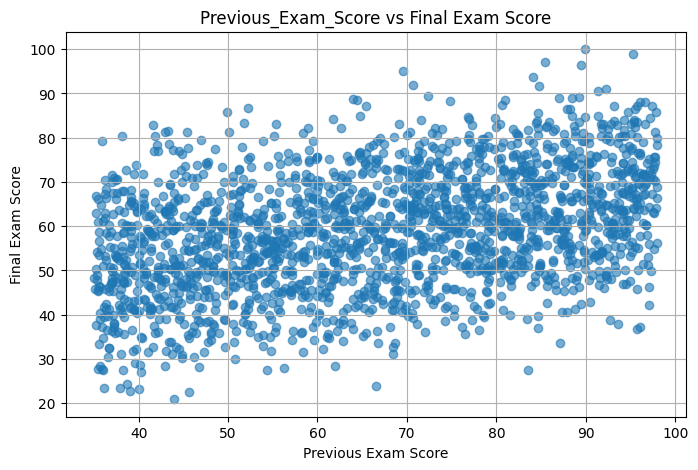

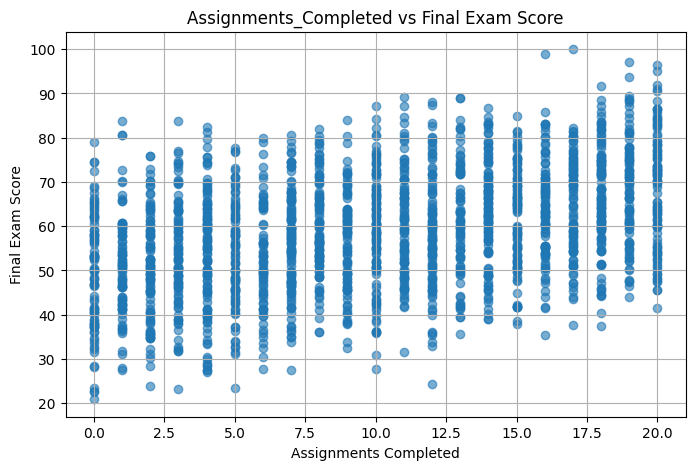

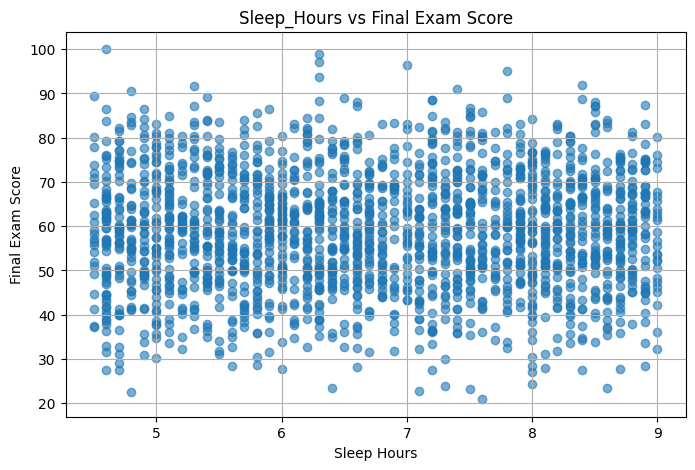

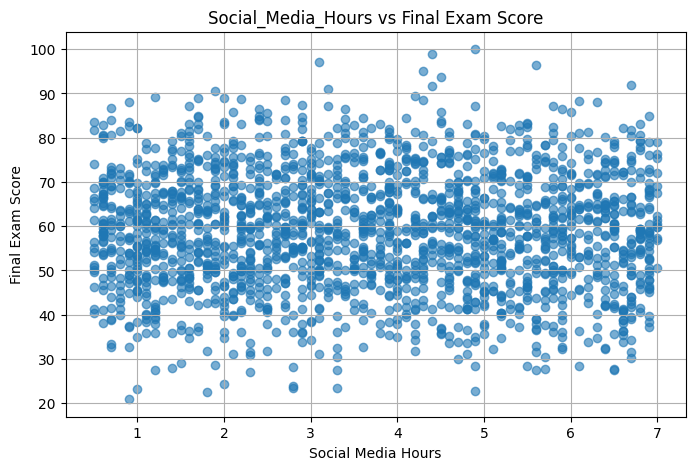

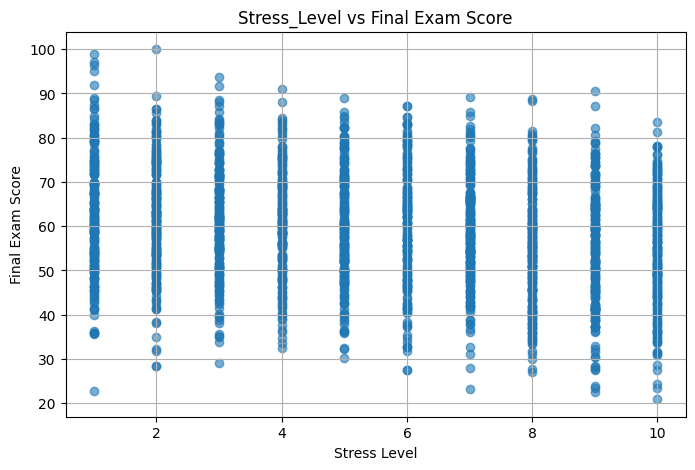

In [9]:

numeric_cols = [
    'Age',
    'Study_Hours_Per_Day',
    'Attendance_Percentage',
    'Previous_Exam_Score',
    'Assignments_Completed',
    'Sleep_Hours',
    'Social_Media_Hours',
    'Stress_Level'
]

for col in numeric_cols:
    plt.figure(figsize=(8,5))
    plt.scatter(df[col], df["Final_Exam_Score"], alpha=0.6)
    plt.title(f"{col} vs Final Exam Score")
    plt.xlabel(col.replace("_", " "))
    plt.ylabel("Final Exam Score")
    plt.grid(True)
    plt.show()

In [10]:
df.dtypes

Gender                    object
Age                        int64
Study_Hours_Per_Day      float64
Attendance_Percentage    float64
Previous_Exam_Score      float64
Assignments_Completed      int64
Sleep_Hours              float64
Social_Media_Hours       float64
Extra_Curricular          object
Stress_Level               int64
Final_Exam_Score         float64
dtype: object

In [11]:
# Label Encoding - [Gender, Extra_Curricular]

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])
df['Extra_Curricular'] = encoder.fit_transform(df['Extra_Curricular'])

In [12]:
df.columns

Index(['Gender', 'Age', 'Study_Hours_Per_Day', 'Attendance_Percentage',
       'Previous_Exam_Score', 'Assignments_Completed', 'Sleep_Hours',
       'Social_Media_Hours', 'Extra_Curricular', 'Stress_Level',
       'Final_Exam_Score'],
      dtype='object')

In [13]:
X = df.drop(columns=['Final_Exam_Score'])
y = df['Final_Exam_Score']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train

,Gender,Age,Study_Hours_Per_Day,Attendance_Percentage,Previous_Exam_Score,Assignments_Completed,Sleep_Hours,Social_Media_Hours,Extra_Curricular,Stress_Level
968,1,24,2.5,81.6,70.4,7,4.9,4.7,1,2
240,1,20,2.7,78.5,79.2,1,8.5,5.8,1,2
819,0,19,4.1,70.2,62.6,11,7.9,2.6,0,4
692,1,18,7.8,55.7,88.2,11,6.9,2.0,1,2
420,0,17,6.2,84.7,67.8,15,8.1,4.8,1,9
...,...,...,...,...,...,...,...,...,...,...
1130,1,21,7.4,67.1,74.0,1,6.9,5.5,1,7
1294,0,24,6.2,56.6,54.2,6,7.2,6.4,0,8
860,1,20,2.5,96.1,92.9,2,8.1,6.1,1,1
1459,0,19,5.3,90.6,53.7,1,5.1,0.6,0,8


In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [21]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.3 , 0.01, 4.17,...,-0.3 , 0.01,-1.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['Gender','Age','Study_Hours_Per_Day',...,'Social_Media_Hours', 'Extra_Curricular','Stress_Level']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.626
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


In [22]:
y_pred = model.predict(X_test)

In [23]:
y_pred

array([72.19635085, 70.28165009, 54.59252048, 41.73346098, 57.01288315,
       48.9081279 , 70.00581369, 68.28718644, 65.5695201 , 50.78109286,
       52.88307686, 63.49208168, 36.39847135, 56.53218079, 63.91052991,
       54.78184169, 57.65720224, 50.34371149, 60.83398019, 67.98802784,
       41.9323477 , 72.84380299, 59.87777236, 41.3970166 , 49.9746427 ,
       60.73005083, 48.29238466, 48.76641281, 38.55165208, 60.34191687,
       34.20720602, 48.21190138, 40.20802399, 67.96222181, 50.80905305,
       76.15712625, 62.20675031, 40.54536263, 77.3688782 , 57.1173379 ,
       45.09306998, 46.13626996, 64.44413266, 54.21803032, 44.66439531,
       56.51747298, 79.33100639, 62.32846976, 54.84736618, 61.908287  ,
       42.91316989, 56.68889082, 81.51324895, 80.98907003, 73.63499496,
       49.87558948, 74.94709742, 52.80026853, 32.96554192, 59.50214576,
       40.40394729, 65.06390005, 58.92118758, 62.6997365 , 29.1852246 ,
       75.39198074, 49.29747592, 37.128667  , 73.47823878, 65.57

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

MAE : 3.760560461451614
MSE : 21.698874069432595
RMSE: 4.658205026556108
R²  : 0.8924029620167339


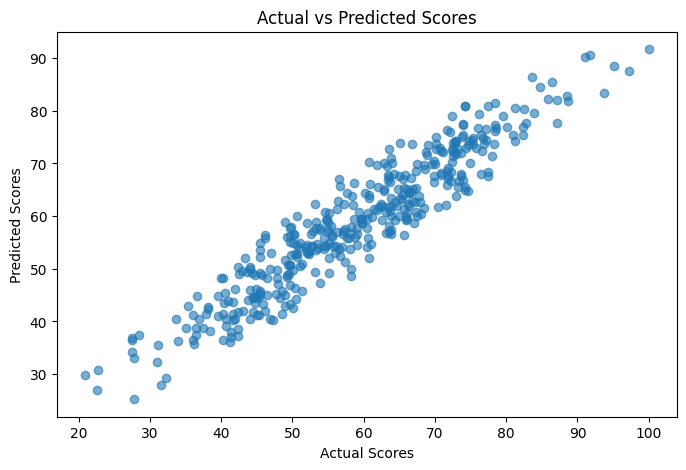

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")

plt.show()

In [28]:
import pickle

with open("student_score_model.pkl", "wb") as file:
    pickle.dump(model, file)